> Tip: If your run directories already contain `orbit_results.pkl` (as written in the workflow inside `post_mcmc.ipynb`), those orbits will be plotted automatically. If not, only members are shown.

# Plot Multiple Streams and Orbits
Provide a list of stream run directories (each containing a membership FITS and optional `orbit_results.pkl`), and this notebook will plot all members and orbits on one Mollweide figure.

In [44]:
import os
import pickle
import glob
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from galpy.potential import MWPotential2014
import post_mcmc
import orbit_functions as ofuncs


def zero_360_to_180(ra):
    ra = np.asarray(ra).copy()
    mask = ra > 180
    ra[mask] -= 360
    return ra


def get_mem_path(directory):
    files = os.listdir(directory)
    for file in files:
        if (('0.5%_mem' in file) or ('50%_mem' in file)) and file.endswith('.fits'):
            return os.path.join(directory, file)
    for file in files:
        if file.endswith('.fits'):
            return os.path.join(directory, file)
    return None


def load_stream(mem_path):
    stream_data, run_dir = post_mcmc.load_stream_mems(mem_path)
    return stream_data, run_dir


def _load_orbit_from_pkl(pkl_path):
    try:
        with open(pkl_path, 'rb') as f:
            data = pickle.load(f)
        if isinstance(data, dict) and ('results_o' in data) and ('orbit' in data):
            return data.get('results_o'), data.get('orbit')
    except Exception:
        pass
    return None, None


def load_orbit(run_dir):
    """Search for orbit pickles in run_dir and sibling folders with same stream key."""
    # 1) canonical path
    pkl = os.path.join(run_dir, 'orbit_results.pkl')
    if os.path.exists(pkl):
        res, orb = _load_orbit_from_pkl(pkl)
        if res is not None:
            print(f"orbit: {os.path.basename(run_dir)}")
            return res, orb

    # 2) any orbit-like pickle inside run_dir
    candidates = sorted(glob.glob(os.path.join(run_dir, '*orbit*.pkl')))
    for c in candidates:
        res, orb = _load_orbit_from_pkl(c)
        if res is not None:
            print(f"orbit: {os.path.basename(run_dir)}")
            return res, orb

    # 3) look in sibling run directories with same stream key
    base = os.path.basename(os.path.normpath(run_dir))
    parent = os.path.dirname(os.path.normpath(run_dir))
    stream_key = base.split('_')[0]  # e.g., 'Gaia-12-I21'
    try:
        for sub in os.listdir(parent):
            sub_path = os.path.join(parent, sub)
            if (sub != base) and os.path.isdir(sub_path) and (stream_key in sub):
                pkl_sib = os.path.join(sub_path, 'orbit_results.pkl')
                if os.path.exists(pkl_sib):
                    res, orb = _load_orbit_from_pkl(pkl_sib)
                    if res is not None:
                        print(f"orbit: {sub}")
                        return res, orb
                for c in sorted(glob.glob(os.path.join(sub_path, '*orbit*.pkl'))):
                    res, orb = _load_orbit_from_pkl(c)
                    if res is not None:
                        print(f"orbit: {sub}")
                        return res, orb
    except Exception:
        pass

    print(f"no-orbit: {os.path.basename(run_dir)}")
    return None, None


def to_mollweide_radec(ra_deg, dec_deg):
    ra_wrapped = zero_360_to_180(ra_deg)
    return np.radians(ra_wrapped), np.radians(dec_deg)


def get_col(data, candidates):
    for k in candidates:
        try:
            if hasattr(data, 'colnames') and (k in data.colnames):
                return np.asarray(data[k], dtype=float)
            if hasattr(data, 'dtype') and data.dtype.names and (k in data.dtype.names):
                return np.asarray(data[k], dtype=float)
        except Exception:
            continue
    raise KeyError(f'None of columns {candidates} found')


def extract_orbit_radec(orbit):
    if orbit is None:
        return None, None
    if isinstance(orbit, dict):
        for k_ra, k_dec in [('o_ra', 'o_dec'), ('ra', 'dec'), ('RA', 'DEC')]:
            if k_ra in orbit and k_dec in orbit:
                try:
                    return np.asarray(orbit[k_ra], dtype=float), np.asarray(orbit[k_dec], dtype=float)
                except Exception:
                    pass
        return None, None
    try:
        if hasattr(orbit, 'integrate') and hasattr(orbit, 'ra') and hasattr(orbit, 'dec'):
            fw = np.linspace(0., 0.05, 1001) * u.Gyr
            bw = np.linspace(0., -0.05, 1001) * u.Gyr
            orbit.integrate(bw, MWPotential2014)
            ra_bw = np.asarray(orbit.ra(bw).value, dtype=float)
            dec_bw = np.asarray(orbit.dec(bw).value, dtype=float)
            orbit.integrate(fw, MWPotential2014)
            ra_fw = np.asarray(orbit.ra(fw).value, dtype=float)
            dec_fw = np.asarray(orbit.dec(fw).value, dtype=float)
            ra = np.concatenate([ra_bw[::-1], ra_fw])
            dec = np.concatenate([dec_bw[::-1], dec_fw])
            return ra, dec
    except Exception:
        return None, None
    return None, None


print('Imports and helpers loaded.')

Imports and helpers loaded.


## Configure stream run directories
Set `stream_dirs` to the set of run folders you want to include. If left empty, we'll auto-discover some folders under `./runs/`.

In [45]:
# Example: provide absolute or relative paths to run directories
stream_dirs = [
    '/Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/Gaia-6-I21_250922_ac/',
    '/Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/Gaia-12-I21_250918_badscipy/',
    '/Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/Sylgr-I21_250915_spline_save/',
    '/Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/C-19-I21_250911_jo_1d/'
]
# If not provided, try to discover under ./runs/
if len(stream_dirs) == 0:
    runs_root = os.path.abspath(os.path.join(os.getcwd(), 'runs'))
    if os.path.isdir(runs_root):
        # pick a few directories that look like runs
        stream_dirs = [os.path.join(runs_root, d) for d in os.listdir(runs_root) if os.path.isdir(os.path.join(runs_root, d))][:6]
        print('Auto-discovered run dirs:', len(stream_dirs))
    else:
        print('No runs/ directory found next to this notebook. Please set stream_dirs manually.')
stream_dirs

['/Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/Gaia-6-I21_250922_ac/',
 '/Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/Gaia-12-I21_250918_badscipy/',
 '/Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/Sylgr-I21_250915_spline_save/',
 '/Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/C-19-I21_250911_jo_1d/']

## Load streams and (optional) orbits

In [46]:
loaded = []  # list of dicts with keys: label, data, run_dir, results_o, orbit
for d in stream_dirs:
    print(f'== Processing {d}')
    mem_path = get_mem_path(d)
    print('  mem_path:', mem_path)
    if mem_path is None:
        print(f'[skip] No membership FITS found in {d}')
        continue
    try:
        stream_data, run_dir = load_stream(mem_path)
        print('  run_dir:', run_dir)
    except Exception as e:
        print(f'[skip] Failed to load stream from {mem_path}: {e}')
        continue
    label = stream_label_from_dir(d)
    results_o, orbit_obj = load_orbit(run_dir)
    loaded.append({'label': label, 'data': stream_data, 'run_dir': run_dir, 'results_o': results_o, 'orbit': orbit_obj})
print(f'Loaded {len(loaded)} streams')

== Processing /Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/Gaia-6-I21_250922_ac/
  mem_path: /Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/Gaia-6-I21_250922_ac/Gaia-6-I21_phi2_spline_50%_mem.fits
  run_dir: /Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/Gaia-6-I21_250922_ac
orbit: Gaia-6-I21_250922_ac
== Processing /Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/Gaia-12-I21_250918_badscipy/
  mem_path: /Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/Gaia-12-I21_250918_badscipy/Gaia-12-I21_phi2_spline_50%_mem.fits
  run_dir: /Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/Gaia-12-I21_250918_badscipy
orbit: Gaia-12-I21_250917_badscipy
== Processing /Users/nasserm/Documents/vscode/research/streamTut/DESI-DR1_streamTutorial/runs/Sylgr-I21_250915_spline_save/
  mem_path: /Users/nasserm/Documents/

## Plot all members and orbits on a Mollweide figure

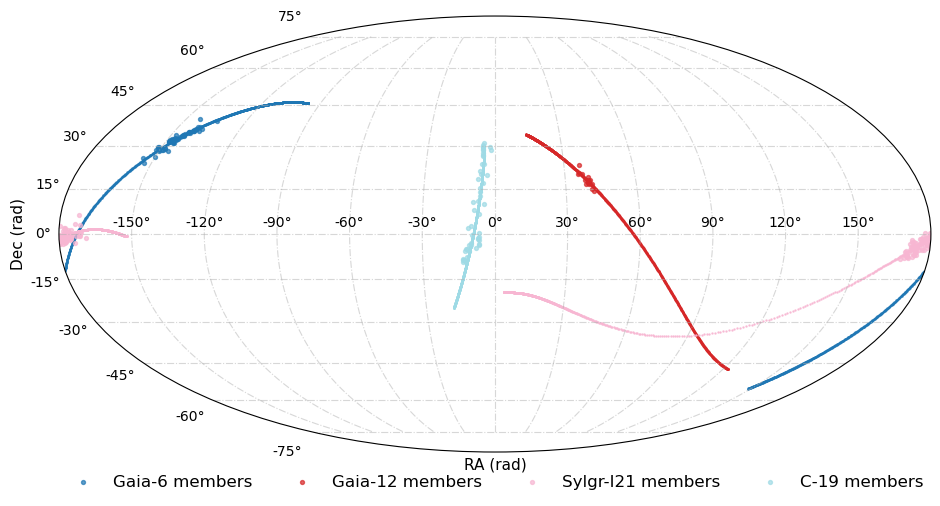

In [49]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='mollweide')
colors = plt.cm.tab20(np.linspace(0, 1, max(1, len(loaded))))

for i, item in enumerate(loaded):
    data = item['data']
    label = item['label']
    col = colors[i % len(colors)]

    # Members
    try:
        ra_deg = get_col(data, ['TARGET_RA', 'RA'])
        dec_deg = get_col(data, ['TARGET_DEC', 'DEC'])
    except Exception as e:
        print(f'[skip members] {label}: {e}')
        continue
    x_m, y_m = to_mollweide_radec(ra_deg, dec_deg)
    ax.scatter(x_m, y_m, s=8, color=col, alpha=0.7, label=f'{label} members')

    # Orbit as scatter (prefer saved, fallback to reconstruction)
    ra_o, dec_o = extract_orbit_radec(item.get('orbit'))
    if ra_o is None or dec_o is None:
        res = item.get('results_o')
        if res is not None and hasattr(res, 'x'):
            prog_ra = float(np.nanmean(ra_deg))
            fw = np.linspace(0., 0.05, 801) * u.Gyr
            bw = np.linspace(0., -0.05, 801) * u.Gyr
            try:
                o_ra, o_dec, _, _, _, _ = ofuncs.orbit_model(res.x[0:5], prog_ra, bw, fw)
                ra_o, dec_o = np.asarray(o_ra, dtype=float), np.asarray(o_dec, dtype=float)
            except Exception as e:
                print(f'[orbit skipped for {label}]: {e}')
                ra_o, dec_o = None, None
    if ra_o is not None and dec_o is not None:
        x_o, y_o = to_mollweide_radec(ra_o, dec_o)
        ax.scatter(x_o, y_o, s=0.5, color=col, alpha=0.9)  # no separate legend entry

# Cosmetics
ax.grid(True, zorder=0, alpha=0.5, ls='-.')
ax.set_xlabel('RA (rad)', fontsize=11)
ax.set_ylabel('Dec (rad)', fontsize=11)
# Legend: members only
handles, leg_labels = ax.get_legend_handles_labels()
from collections import OrderedDict
seen = OrderedDict()
for h, l in zip(handles, leg_labels):
    if l not in seen:
        seen[l] = h
ax.legend(seen.values(), seen.keys(), loc='lower center', bbox_to_anchor=(0.5, -0.12), ncol=4, fontsize=12, frameon=False)
plt.tight_layout()
plt.show()

In [48]:
# Optional: save figure
save_path = None  # e.g., 'figures_draft/multi_streams_mollweide.png'
if save_path:
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    fig.savefig(save_path, bbox_inches='tight', dpi=300)
print('Done')

Done
